<a href="https://colab.research.google.com/github/28JOY/Allergy-Detection-Model/blob/main/AI_Powered_Face_Mask_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJECT 5:** AI-Powered Face Mask Detection System

### **Step-1: Upload the saved model zip file (downloaded from Teachable Machine) in Google Colab**

In [ ]:
#@title Upload the saved model zip file and Run this cell to Unzip it

import os
from IPython.display import clear_output

# Get all .zip files in the current folder
zip_files = [f for f in os.listdir('.') if f.endswith('.zip')]

if not zip_files:
    print("Please upload the saved model zip file (downloaded from Teachable Machine) in Google Colab.")
else:
    !unzip "$(ls | grep '.zip')"
    clear_output()
    print("Model Unzipped successfully!")

Model Unzipped successfully!


### **Step-2: Load Model and Class Labels**

In [ ]:
#@title Run this cell to Import required libraries

import tensorflow as tf
from PIL import Image, ImageOps
import numpy as np
# Disable scientific notation for clarity
np.set_printoptions(suppress=True)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
#@title Run this cell to Load the SavedModel

# ----------------------------
# Load SavedModel
# ----------------------------
saved_model = tf.saved_model.load("model.savedmodel")

# Get the serving function
infer = saved_model.signatures["serving_default"]

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
#@title Run this cell to Load Class labels

class_names = open("labels.txt", "r").readlines()
class_names = [name.split()[-1] for name in class_names]

print("Class labels loaded successfully!")
print(class_names)

Class labels loaded successfully!
['with_mask', 'without_mask', 'partial_mask']


### **Step-3: Upload a Test image and Get Prediction**

array([[[126, 117, 112],
        [123, 114, 109],
        [ 69,  61,  56],
        ...,
        [ 57,  46,  41],
        [ 42,  31,  28],
        [ 60,  49,  45]],

       [[ 94,  85,  80],
        [ 57,  48,  43],
        [ 40,  32,  27],
        ...,
        [ 72,  61,  56],
        [ 62,  51,  48],
        [ 56,  45,  41]],

       [[ 56,  47,  42],
        [ 40,  30,  24],
        [ 58,  49,  43],
        ...,
        [ 75,  63,  60],
        [ 64,  53,  48],
        [ 47,  36,  32]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [252, 252, 249],
        [248, 248, 247]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [241, 241, 236],
        [253, 253, 251],
        [248, 248, 247]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [224, 221, 216],
        [255, 255, 255],
        [253, 253, 250]]], dtype=uint8)
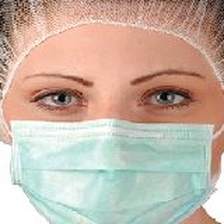

In [ ]:
#@title Upload a Face-Mask Test image, provide its file name, then Run this cell

# "Upload a test image in Colab and provide its file name here (eg. trash28.jpg)"
img_file = "novas (3).png"  #@param {type:"string"}

# Prepare the input image
data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)

image = Image.open(img_file).convert("RGB")
size = (224, 224)
image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)

image_array = np.asarray(image)
normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1
data[0] = normalized_image_array

# Show image
image_array

In [ ]:
#@title Run this cell to Get Prediction for the test image

# ----------------------------
# Run Prediction
# ----------------------------
# Convert numpy → tensor
input_tensor = tf.convert_to_tensor(data)

# Call the SavedModel signature
output = infer(input_tensor)

# SavedModel may return a dict – get the first output tensor
prediction = list(output.values())[0].numpy()

# Decode prediction
index = np.argmax(prediction)
class_name = class_names[index].strip()
confidence_score = prediction[0][index]

# Print results
print("Class:", class_name)
print("Confidence Score:", confidence_score)


Class: with_mask
Confidence Score: 0.789355


### **Step-4: Create a Gradio Interface**

Use the Gemini present within Google Colab notebook ( <img src='https://drive.google.com/uc?id=19N2vjh7eihxQ3qj9uavYblyveidsLKsf' width=30> ), to generate code for creating a Gradio Interface with below features.


Inputs:
- `Gradio File` to let user upload an image file

Outputs:
- `Gradio Image` to show the image uploaded by user
- `Gradio Textbox` to show the predicted class label and confidence score

Logic:
- The user input image should go to the face-mask detection model (trained on Teachable Machine)
- The predicted face-mask-label and the user uploaded image should be seen in the UI output

In [ ]:
import gradio as gr
from PIL import Image, ImageOps
import numpy as np
import tensorflow as tf

# Ensure the model and class_names are loaded (assuming they are already in the environment)
# For a standalone script, you might need to reload them here.
# For this Colab context, they are globally available after previous cell executions.

# Define the prediction function
def classify_image(image_file):
    if image_file is None:
        return None, "Please upload an image."

    # Open the image using PIL
    image = Image.open(image_file.name).convert("RGB")

    # Prepare the input image for the model
    size = (224, 224)
    image_for_model = ImageOps.fit(image, size, Image.Resampling.LANCZOS)
    image_array = np.asarray(image_for_model)
    normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1
    data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)
    data[0] = normalized_image_array

    # Convert numpy \u2192 tensor
    input_tensor = tf.convert_to_tensor(data)

    # Call the SavedModel signature
    output = infer(input_tensor)

    # SavedModel may return a dict \u2013 get the first output tensor
    prediction = list(output.values())[0].numpy()

    # Decode prediction
    index = np.argmax(prediction)
    class_name = class_names[index].strip()
    confidence_score = prediction[0][index]

    # Format the output string
    output_text = f"Class: {class_name}\nConfidence Score: {confidence_score:.2f}"

    return image, output_text

print("Prediction function defined!")

Prediction function defined!


In [ ]:
# Create the Gradio interface
interface = gr.Interface(
    fn=classify_image,
    inputs=gr.File(type="filepath", label="Upload an image"), # Gradio File component for image upload
    outputs=[
        gr.Image(type="pil", label="Uploaded Image"), # Gradio Image component to show the uploaded image
        gr.Textbox(label="Prediction") # Gradio Textbox for class label and confidence
    ],
    title="AI-Powered Face Mask Detection System",
    description="Upload an image to detect if a person is wearing a mask, no mask, or a partial mask."
)

print("Gradio interface created!")

Gradio interface created!


In [ ]:
# Launch the Gradio interface
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c89700fc97b6c51b9a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
#import gradio as gr

---

<center>
$END$
</center>

---